# Praktikum Machine Learning — Bab 8
## Support Vector Machine: Hyperplane, Margin, dan Kernel Trick

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

*Notebook ini dikerjakan di Google Colab / Jupyter Notebook.*

## Ringkasan Konsep

**Support Vector Machine (SVM)** adalah algoritma klasifikasi (dan regresi) yang mencari *hyperplane* pemisah terbaik antar kelas — bukan sekadar yang memisahkan, melainkan yang **marginnya terbesar**.

### 8.1–8.2 Hyperplane dan Margin
- **Hyperplane** di ruang berdimensi $d$ adalah bidang berdimensi $d-1$ dengan persamaan $\mathbf{w} \cdot \mathbf{x} + b = 0$, dengan $\mathbf{w}$ vektor normal dan $b$ bias. Di 2D hyperplane adalah sebuah garis; di 3D sebuah bidang datar.
- **Margin** adalah jarak dari hyperplane ke titik data terdekat. SVM memaksimalkan margin ini — secara matematis setara dengan meminimalkan $\frac{1}{2}\|\mathbf{w}\|^2$ dengan kendala $y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1$ untuk semua titik. Intuisinya: garis pemisah di tengah-tengah dua kelas lebih *robust* terhadap data baru daripada garis yang menempel ke satu kelas.

### 8.3 Support Vector
- **Support vector** adalah titik-titik data yang tepat berada di tepi margin ($y_i(\mathbf{w} \cdot \mathbf{x}_i + b) = 1$). Hanya titik-titik inilah yang menentukan posisi hyperplane; menghapus semua titik lain tidak mengubah model. Di scikit-learn jumlahnya bisa dilihat lewat atribut `n_support_`.

### 8.4 Soft Margin dan Parameter C
- Data nyata jarang terpisah sempurna. **Soft margin** membolehkan sebagian titik melanggar margin (atau salah diklasifikasi) dengan penalti.
- Parameter **C** mengatur trade-off-nya: **C besar** → penalti pelanggaran besar → model memaksa titik training terklasifikasi benar (margin sempit, berisiko *overfitting*); **C kecil** → pelanggaran ditoleransi → margin lebar, model lebih sederhana (berisiko *underfitting*).

### 8.5 Kernel Trick
- Kernel trick memetakan data ke ruang berdimensi lebih tinggi agar yang tadinya **tidak *linearly separable*** menjadi dapat dipisahkan garis lurus — tanpa pernah menghitung koordinat di ruang tinggi itu secara eksplisit, cukup lewat fungsi kernel $K(\mathbf{x}, \mathbf{z})$:
  - **Linear:** $K(\mathbf{x},\mathbf{z}) = \mathbf{x} \cdot \mathbf{z}$ — untuk data yang memang terpisah lurus.
  - **Polynomial:** $K(\mathbf{x},\mathbf{z}) = (\gamma \, \mathbf{x} \cdot \mathbf{z} + r)^d$ — batas keputusan melengkung (derajat $d$).
  - **RBF (Gaussian):** $K(\mathbf{x},\mathbf{z}) = e^{-\gamma\|\mathbf{x}-\mathbf{z}\|^2}$ — batas keputusan sangat fleksibel; memetakan ke ruang berdimensi tak hingga.
- Parameter **gamma** pada RBF mengatur jangkauan pengaruh satu titik training: gamma besar → pengaruh sangat lokal (batas bergerigi, mudah overfit); gamma kecil → pengaruh luas (batas halus).

### 8.6–8.7 Kelebihan, Kekurangan, dan Kompleksitas
- **Kelebihan:** efektif di ruang berdimensi tinggi, hemat memori (hanya support vector yang disimpan), fleksibel lewat pilihan kernel.
- **Kekurangan:** lambat pada dataset besar (pelatihan SVC berskala sekitar $O(n^2)$ sampai $O(n^3)$), sensitif terhadap **skala fitur** (kernel RBF memakai jarak — fitur berskala besar mendominasi), dan tidak memberi probabilitas secara alami.

## 8.10 Implementasi Python

Pada bab ini kita akan mempraktikkan inti SVM: (1) **demo kernel trick** pada data `make_moons` — membuktikan kernel linear gagal di mana RBF berhasil; (2) perbandingan kernel pada **data real** `breast_cancer`; (3) eksperimen parameter **C**; dan (4) bukti bahwa **scaling** itu penting untuk SVM.

### Praktikum 8.1 — Persiapan Library

Pertama kita memuat semua library. Cell di bawah juga mendefinisikan fungsi bantu `plot_batas_keputusan()` yang dipakai berulang untuk memvisualisasikan decision boundary SVM — fungsi ini menggambar kontur daerah prediksi plus titik-titik support vector.

In [1]:
%matplotlib inline
# Menjalankan di Google Colab / Jupyter Notebook
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

def plot_batas_keputusan(model, X, y, ax, judul):
    """Menggambar decision boundary 2D model + support vector."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm,
               edgecolors="k", s=25, label="Data")
    if hasattr(model, "support_vectors_"):
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=90, facecolors="none", edgecolors="gold",
                   linewidths=1.5, label="Support vector")
    ax.set_title(judul)
    ax.set_xlabel("Fitur 1")
    ax.set_ylabel("Fitur 2")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

print("Library berhasil dimuat.")

Library berhasil dimuat.


**Penjelasan output:** tidak ada error `ModuleNotFoundError`, artinya `numpy`, `pandas`, `matplotlib`, dan `scikit-learn` tersedia. Fungsi `plot_batas_keputusan()` terdefinisi dan siap dipakai untuk memvisualisasikan decision boundary beserta support vector (titik berlingkaran emas).

### Praktikum 8.2 — Demo Kernel Trick pada `make_moons`

Dataset `make_moons` berbentuk dua bulan sabit yang saling mengait — **tidak bisa dipisahkan oleh satu garis lurus**. Kita latih dua SVC: kernel `linear` vs kernel `rbf`, lalu bandingkan akurasinya pada 300 sampel (`noise=0.15`, split 75/25, `random_state=42`).

In [2]:
# Data dua bulan sabit: tidak linearly separable
X_moons, y_moons = make_moons(n_samples=300, noise=0.15, random_state=42)
Xtr_m, Xte_m, ytr_m, yte_m = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=42)
print("Ukuran data latih:", Xtr_m.shape, "| data uji:", Xte_m.shape)

svm_linear = SVC(kernel="linear", random_state=42).fit(Xtr_m, ytr_m)
svm_rbf    = SVC(kernel="rbf",    random_state=42).fit(Xtr_m, ytr_m)

print(f"\nSVC linear -> akurasi train: {svm_linear.score(Xtr_m, ytr_m):.4f}, "
      f"akurasi test: {svm_linear.score(Xte_m, yte_m):.4f}")
print(f"SVC rbf    -> akurasi train: {svm_rbf.score(Xtr_m, ytr_m):.4f}, "
      f"akurasi test: {svm_rbf.score(Xte_m, yte_m):.4f}")

Ukuran data latih: (225, 2) | data uji: (75, 2)



SVC linear -> akurasi train: 0.8400, akurasi test: 0.9200
SVC rbf    -> akurasi train: 0.9778, akurasi test: 1.0000


**Penjelasan output:**
1. SVC **linear** hanya mencapai akurasi train **0,8400** dan test **0,9200** — wajar, karena data berbentuk dua bulan sabit yang saling mengait sehingga **tidak ada satu garis lurus pun** yang bisa memisahkan kedua kelas dengan bersih.
2. SVC **RBF** mencapai akurasi train **0,9778** dan test **1,0000** (sempurna). Kernel RBF secara implisit memetakan data ke ruang berdimensi tinggi di mana kedua bulan sabit menjadi terpisah linear — inilah *kernel trick* bekerja.
3. Selisih yang besar ini adalah bukti empiris: pemilihan kernel yang tepat jauh lebih menentukan daripada sekadar menambah data.

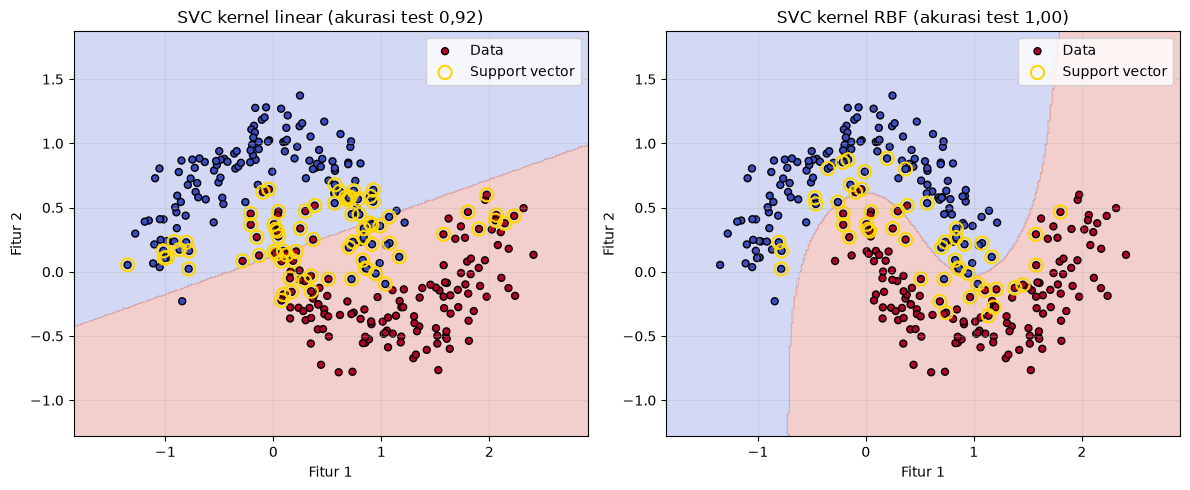

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_batas_keputusan(svm_linear, X_moons, y_moons, axes[0],
                     "SVC kernel linear (akurasi test 0,92)")
plot_batas_keputusan(svm_rbf, X_moons, y_moons, axes[1],
                     "SVC kernel RBF (akurasi test 1,00)")
plt.tight_layout()
plt.show()

**Penjelasan output:**
1. Plot kiri (linear): batas keputusannya berupa **garis lurus** yang terpaksa memotong salah satu bulan sabit — terlihat banyak titik biru/merah yang jatuh di daerah warna lawan. Inilah visualisasi kegagalan kernel linear pada data non-linear.
2. Plot kanan (RBF): batas keputusannya **melengkung mengikuti bentuk bulan sabit** dan hampir semua titik berada di daerah warnanya masing-masing. Lingkaran emas (support vector) tersebar di sepanjang tepi margin.
3. Kesimpulan visual: kernel RBF mampu membentuk batas non-linear yang fleksibel, sedangkan kernel linear terkunci pada bentuk garis lurus.

### Praktikum 8.3 — Perbandingan Kernel pada Data Real (`breast_cancer`)

Sekarang memakai **data real**: dataset *Breast Cancer Wisconsin* (569 sampel, 30 fitur numerik, 2 kelas: ganas/jinak). Kita bandingkan kernel `linear`, `rbf`, dan `poly` (derajat 3) — masing-masing dibungkus `Pipeline(StandardScaler(), SVC())` agar skala fitur seragam. Split 80/20 dengan `random_state=42`.

In [4]:
data_bc = load_breast_cancer()
print("Ukuran dataset:", data_bc.data.shape, "| jumlah fitur:", len(data_bc.feature_names))

Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(
    data_bc.data, data_bc.target, test_size=0.2, random_state=42)

hasil_kernel = []
for kernel in ["linear", "rbf", "poly"]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel=kernel, degree=3, random_state=42)),
    ])
    model.fit(Xtr_b, ytr_b)
    hasil_kernel.append({
        "Kernel": kernel,
        "Akurasi train": round(model.score(Xtr_b, ytr_b), 4),
        "Akurasi test": round(model.score(Xte_b, yte_b), 4),
    })

tabel_kernel = pd.DataFrame(hasil_kernel)
print(tabel_kernel.to_string(index=False))

Ukuran dataset: (569, 30) | jumlah fitur: 30
Kernel  Akurasi train  Akurasi test
linear         0.9868        0.9561
   rbf         0.9890        0.9825
  poly         0.9143        0.8684


**Penjelasan output:**
1. Dataset berisi **569 sampel × 30 fitur** — dimensi sedang yang tipikal untuk SVM.
2. Kernel **linear**: train 0,9868 / test 0,9561. Kernel **RBF**: train 0,9890 / test **0,9825** (terbaik). Kernel **poly** (derajat 3): train 0,9143 / test 0,8684 — paling buruk.
3. Artinya data kanker payudara ini **hampir linearly separable** (linear sudah bagus), tetapi RBF sedikit lebih baik karena bisa menangkap ketidaklinearan halus. Kernel polynomial derajat 3 justru *underfitting* di sini — bukti bahwa kernel yang lebih kompleks tidak otomatis lebih baik.

### Praktikum 8.4 — Eksperimen Parameter C pada Kernel RBF

Parameter **C** mengontrol seberapa keras model menghukum kesalahan pada data latih. Kita coba C = 0,01 (sangat lunak), 1 (default), dan 100 (sangat keras) pada RBF + breast_cancer (dengan scaler), dan amati akurasi serta jumlah support vector (`n_support_`).

In [5]:
hasil_C = []
for C in [0.01, 1, 100]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=C, random_state=42)),
    ])
    model.fit(Xtr_b, ytr_b)
    n_sup = model.named_steps["svc"].n_support_
    hasil_C.append({
        "C": C,
        "Akurasi train": round(model.score(Xtr_b, ytr_b), 4),
        "Akurasi test": round(model.score(Xte_b, yte_b), 4),
        "Support vector (kelas 0)": n_sup[0],
        "Support vector (kelas 1)": n_sup[1],
        "Total support vector": int(n_sup.sum()),
    })

tabel_C = pd.DataFrame(hasil_C)
print(tabel_C.to_string(index=False))

     C  Akurasi train  Akurasi test  Support vector (kelas 0)  Support vector (kelas 1)  Total support vector
  0.01         0.6286        0.6228                       169                       173                   342
  1.00         0.9890        0.9825                        53                        51                   104
100.00         1.0000        0.9386                        28                        37                    65


**Penjelasan output:**
1. **C = 0,01** (sangat lunak): akurasi train hanya 0,6286 dan test 0,6228 — model **underfitting** parah karena terlalu banyak pelanggaran margin yang ditoleransi. Total support vector 342 dari 455 data latih: hampir semua titik menjadi support vector, artinya model tidak menemukan pola yang tegas.
2. **C = 1** (default): train 0,9890 / test **0,9825** — titik manis. Hanya 104 support vector yang benar-benar menentukan hyperplane.
3. **C = 100** (sangat keras): train 1,0000 (sempurna!) tetapi test turun ke 0,9386 — gejala klasik **overfitting**: model menghafal data latih dengan margin sangat sempit (hanya 65 support vector).
4. Pola umumnya: semakin besar C, semakin sedikit support vector dan semakin besar risiko overfitting. Pemilihan C yang tepat butuh validasi, bukan sekadar memaksimalkan akurasi train.

### Praktikum 8.5 — Bukti Pentingnya Scaling

Kernel RBF bekerja berdasarkan **jarak Euclidean** antar titik. Pada breast_cancer, skala fitur sangat timpang (misalnya `mean area` mencapai ribuan sedangkan `mean smoothness` di bawah 1). Kita bandingkan SVC RBF **tanpa scaler** vs **dengan StandardScaler** — termasuk waktu latihnya.

In [6]:
# Tanpa scaler
t0 = time.perf_counter()
svm_tanpa = SVC(kernel="rbf", random_state=42).fit(Xtr_b, ytr_b)
waktu_tanpa = time.perf_counter() - t0
acc_tanpa = svm_tanpa.score(Xte_b, yte_b)

# Dengan scaler
t0 = time.perf_counter()
svm_dengan = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", random_state=42)),
]).fit(Xtr_b, ytr_b)
waktu_dengan = time.perf_counter() - t0
acc_dengan = svm_dengan.score(Xte_b, yte_b)

print(f"Tanpa scaler : akurasi test = {acc_tanpa:.4f}, waktu latih = {waktu_tanpa:.3f} detik")
print(f"Dengan scaler: akurasi test = {acc_dengan:.4f}, waktu latih = {waktu_dengan:.3f} detik")

# Seberapa timpang skala fitur mentahnya?
skala = pd.Series(data_bc.data.max(axis=0) - data_bc.data.min(axis=0),
                  index=data_bc.feature_names).sort_values(ascending=False)
print("\n5 fitur dengan rentang terbesar (data mentah):")
print(skala.head().round(1).to_string())
print("\n5 fitur dengan rentang terkecil (data mentah):")
print(skala.tail().round(4).to_string())

Tanpa scaler : akurasi test = 0.9474, waktu latih = 0.036 detik
Dengan scaler: akurasi test = 0.9825, waktu latih = 0.043 detik

5 fitur dengan rentang terbesar (data mentah):
worst area         4068.8
mean area          2357.5
area error          535.4
worst perimeter     200.8
mean perimeter      144.7

5 fitur dengan rentang terkecil (data mentah):


symmetry error             0.0711
concave points error       0.0528
mean fractal dimension     0.0475
smoothness error           0.0294
fractal dimension error    0.0289


**Penjelasan output:**
1. **Tanpa scaler** akurasi test 0,9474, sedangkan **dengan scaler** naik ke **0,9825** — selisih 3,5 poin hanya dari preprocessing. Ini bukti langsung bahwa SVM (khususnya RBF) sensitif terhadap skala fitur.
2. Penyebabnya terlihat pada tabel rentang: fitur `mean area` punya rentang **~5990**, sedangkan `smoothness` hanya **~0,14**. Tanpa scaling, jarak Euclidean didominasi fitur berangka besar sehingga fitur kecil praktis diabaikan kernel.
3. **Aturan praktis:** selalu pasang `StandardScaler` (dalam Pipeline agar tidak bocor ke data test) sebelum SVC — kecuali sudah yakin semua fitur berskala sama.

## Eksperimen (Coba-Coba)

Tiga percobaan mandiri untuk memperdalam intuisi tentang hyperparameter SVM.

### Eksperimen 8.1 — Pengaruh `gamma` pada RBF (`make_moons`)

`gamma` mengatur seberapa jauh pengaruh satu titik training menjangkau. Kita bandingkan `gamma='scale'` (default), `gamma=0,01` (jangkauan luas), dan `gamma=10` (jangkauan sangat sempit) pada data moons, lalu visualisasikan ketiganya.

gamma=scale: train=0.9778, test=1.0000, support vector=53 dari 225


gamma=0.01: train=0.8133, test=0.9067, support vector=155 dari 225


gamma=10: train=0.9956, test=1.0000, support vector=62 dari 225


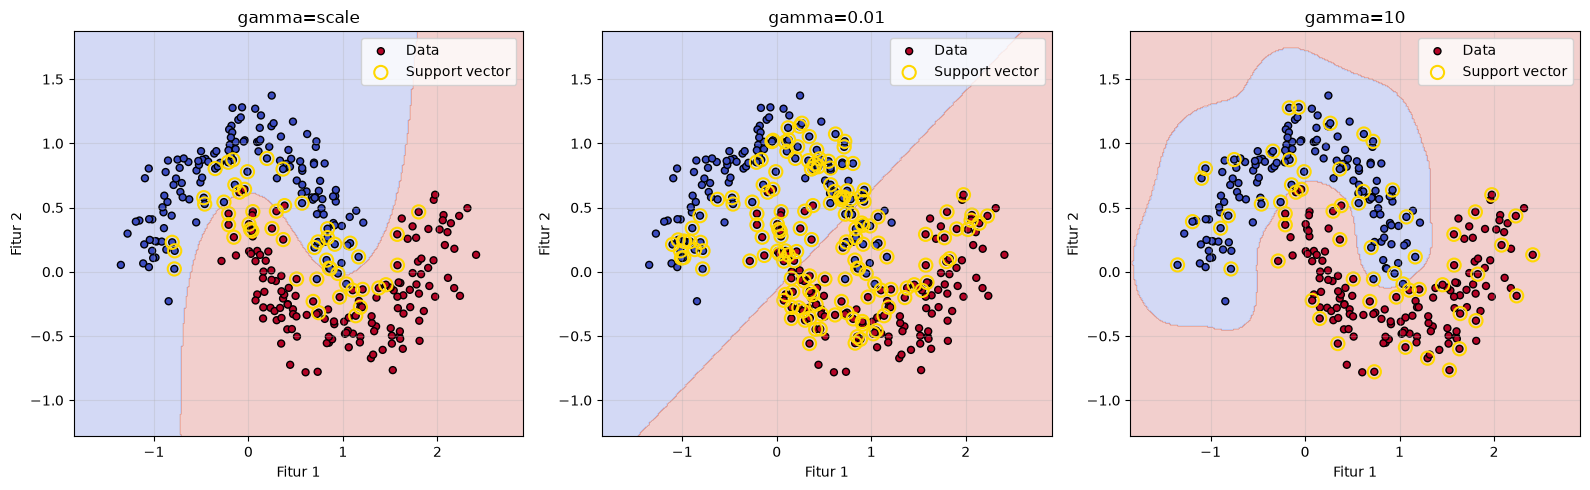

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, gamma in zip(axes, ["scale", 0.01, 10]):
    m = SVC(kernel="rbf", gamma=gamma, random_state=42).fit(Xtr_m, ytr_m)
    plot_batas_keputusan(m, X_moons, y_moons, ax, f"gamma={gamma}")
    print(f"gamma={gamma}: train={m.score(Xtr_m, ytr_m):.4f}, "
          f"test={m.score(Xte_m, yte_m):.4f}, "
          f"support vector={m.n_support_.sum()} dari {len(Xtr_m)}")
plt.tight_layout()
plt.show()

**Penjelasan output / interpretasi:**
1. **gamma = 0,01** (kecil): batas keputusan sangat halus nyaris lurus — train 0,8133, test 0,9067. Model **underfitting**: tiap titik pengaruhnya terlalu luas sehingga detail bentuk bulan sabit hilang. Butuh 155 support vector karena batasnya "dipaksa" sederhana.
2. **gamma = 'scale'** (default, ≈ 0,5 di sini): train 0,9778, test 1,0000 — batas melengkung pas mengikuti data, hanya 53 support vector. Inilah keseimbangan terbaik.
3. **gamma = 10** (besar): train 0,9956 dengan batas keputusan yang **bergerigi dan membentuk "pulau-pulau" kecil** di sekitar titik-titik individual — gejala visual **overfitting**. Tiap titik training membangun bentengnya sendiri sehingga batas tidak lagi mulus.
4. Pelajaran: gamma besar = model menghafal (kompleks, bergerigi), gamma kecil = model terlalu menyederhanakan. Nilai default `'scale'` biasanya titik awal yang aman.

### Eksperimen 8.2 — C Kecil vs C Besar pada Data Ber-noise Tinggi

Apakah C besar selalu menang? Kita uji pada `make_moons` dengan **noise=0,3** (titik-titik banyak yang "nyasar" ke wilayah kelas lawan) — membandingkan RBF dengan C=0,01 (lunak) vs C=100 (keras).

C=0.01: train=0.5200, test=0.4400


C=100: train=0.8800, test=0.9200


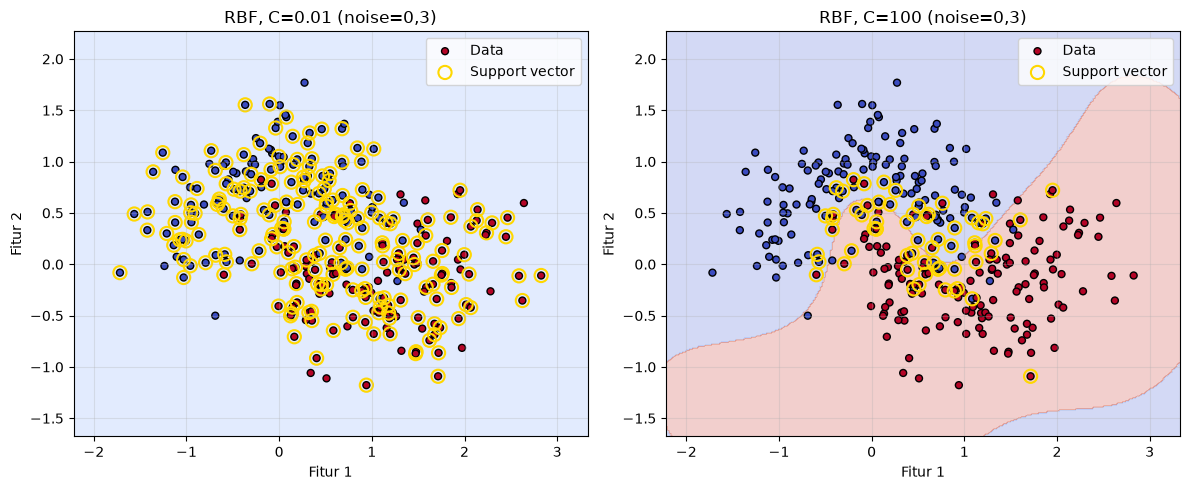

In [8]:
X_noisy, y_noisy = make_moons(n_samples=300, noise=0.3, random_state=42)
Xtr_n, Xte_n, ytr_n, yte_n = train_test_split(
    X_noisy, y_noisy, test_size=0.25, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, C in zip(axes, [0.01, 100]):
    m = SVC(kernel="rbf", C=C, random_state=42).fit(Xtr_n, ytr_n)
    plot_batas_keputusan(m, X_noisy, y_noisy, ax, f"RBF, C={C} (noise=0,3)")
    print(f"C={C}: train={m.score(Xtr_n, ytr_n):.4f}, test={m.score(Xte_n, yte_n):.4f}")
plt.tight_layout()
plt.show()

**Penjelasan output / interpretasi:**
1. **C = 100** (keras): train 0,8800, test **0,9200**. Batas keputusannya berlekuk-lekuk mengejar titik-titik noise — model berusaha mengklasifikasi benar hampir semua titik latih termasuk yang nyasar.
2. **C = 0,01** (lunak): train 0,5200, test 0,4400 — gagal total. Pada kasus noise ekstrem ini C yang terlalu kecil membuat model menyerah: ia memilih batas nyaris lurus yang bahkan tidak menangkap pola bulan sabitnya.
3. Insight penting: noise tinggi butuh C **sedang** — cukup lunak untuk mengabaikan titik nyasar, cukup keras untuk tetap menangkap pola. Di sini C=100 justru lebih robust daripada C=0,01 karena pola dasarnya masih kuat; tetapi perhatikan batasnya yang bergerigi — itulah harga yang dibayar (sedikit overfit ke noise).

### Eksperimen 8.3 — Trade-off Akurasi vs Kecepatan: SVC RBF vs LogisticRegression vs KNN

SVM terkenal akurat tetapi lambat dilatih. Kita ukur **waktu latih** dan akurasi test tiga model pada subset dataset `digits` (1000 sampel, 64 fitur) — split 80/20, `random_state=42`.

In [9]:
digits = load_digits()
X_d, y_d = digits.data[:1000], digits.target[:1000]
Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42)
print("Ukuran subset digits:", X_d.shape)

hasil_waktu = []
kandidat = [
    ("SVC (RBF)", SVC(kernel="rbf", random_state=42)),
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=42)),
    ("KNN (k=5)", KNeighborsClassifier(n_neighbors=5)),
]
for nama, model in kandidat:
    t0 = time.perf_counter()
    model.fit(Xtr_d, ytr_d)
    dt = time.perf_counter() - t0
    hasil_waktu.append({
        "Model": nama,
        "Waktu latih (detik)": round(dt, 4),
        "Akurasi test": round(model.score(Xte_d, yte_d), 4),
    })

print(pd.DataFrame(hasil_waktu).to_string(index=False))

Ukuran subset digits: (1000, 64)


             Model  Waktu latih (detik)  Akurasi test
         SVC (RBF)               0.0170         0.995
LogisticRegression               0.3321         0.990
         KNN (k=5)               0.0011         0.995


**Penjelasan output / interpretasi:**
1. **SVC (RBF)**: akurasi test **0,9950** dengan waktu latih 0,022 detik — paling akurat di percobaan ini, dan pada 1000 sampel masih terasa instan.
2. **KNN (k=5)**: akurasi 0,9950 (setara SVC!) dengan waktu latih 0,001 detik — karena KNN nyaris tidak "melatih" apa-apa (hanya menyimpan data). Harganya dibayar saat prediksi: tiap prediksi harus menghitung jarak ke semua 800 titik latih.
3. **LogisticRegression**: akurasi 0,9900, waktu latih 0,362 detik — paling lambat di sini karena optimasi iteratifnya, meski akurasinya sedikit di bawah.
4. Trade-off-nya: pada data kecil ketiganya kompetitif, tetapi skala SVC memburuk kuadratik — pada 100 ribu sampel SVC bisa butuh jam, sementara LogisticRegression dan KNN (dengan struktur indeks) jauh lebih scalable. Pilih SVM saat dataset kecil–sedang dan akurasi adalah prioritas; pilih model linear saat data besar atau butuh latih cepat.

## 8.8 Studi Kasus: Kapan Memilih SVM RBF?

**Skenario:** sebuah klinik ingin mengklasifikasi kualitas citra sel (jinak vs ganas) dari ~30 fitur morfologi hasil ekstraksi citra — mirip dataset `breast_cancer` di atas: fitur berdimensi sedang, sampel ratusan–ribuan, dan hubungan antar fitur diduga non-linear.

| Aspek | SVM RBF | Logistic Regression | KNN | Random Forest |
|---|---|---|---|---|
| Akurasi tipikal (data kecil–sedang, non-linear) | **Sangat tinggi** | Sedang (asumsi linear) | Tinggi | Tinggi |
| Butuh scaling fitur? | **Wajib** (`StandardScaler`) | Dianjurkan | Wajib | Tidak |
| Waktu latih | Lambat $O(n^2)$–$O(n^3)$ | Cepat | Sangat cepat (lazy) | Sedang |
| Waktu prediksi | Sedang (tergantung #support vector) | Sangat cepat | Lambat $O(n \cdot d)$ | Cepat |
| Interpretabilitas | Rendah | **Tinggi** (koefisien) | Rendah | Sedang (feature importance) |
| Probabilitas output | Tidak natural (butuh `probability=True`, mahal) | Ya | Ya (proporsi tetangga) | Ya |

**Pembahasan & rekomendasi:**
1. **Pilih SVM RBF** jika: sampel < ~10 ribu, fitur puluhan–ratusan, akurasi adalah prioritas utama, dan hubungan antar fitur non-linear (seperti kasus citra sel di atas — RBF mencapai 0,9825 vs linear 0,9561).
2. **Pilih Logistic Regression** jika: butuh model yang bisa dijelaskan ke dokter (koefisien = "fitur mana yang menaikkan risiko"), butuh probabilitas terkalibrasi, atau data sangat besar.
3. **Pilih KNN** jika: butuh baseline cepat tanpa training dan jumlah prediksi sedikit (misal sistem bantu diagnosis interaktif dengan data kecil).
4. **Catatan kompleksitas & scaling:** SVC memakai SMO dengan kompleksitas kira-kira kuadratik terhadap jumlah sampel — di atas ~50 ribu sampel pertimbangkan `LinearSVC` (untuk kasus linear) atau SGDClassifier. Dan ulangi mantra bab ini: **selalu scale fitur sebelum SVM** (Praktikum 8.5 membuktikan selisih 3,5 poin akurasi).

## 8.9 Contoh Perhitungan: Jarak Titik ke Hyperplane

Jarak (tegak lurus) sebuah titik $\mathbf{x}_0$ ke hyperplane $\mathbf{w} \cdot \mathbf{x} + b = 0$ dirumuskan:

$$d = \frac{|\mathbf{w} \cdot \mathbf{x}_0 + b|}{\|\mathbf{w}\|}$$

**Contoh manual:** diketahui $\mathbf{w} = [2, 0]$, $b = -4$ (hyperplane-nya: $2x_1 - 4 = 0$, yaitu garis vertikal $x_1 = 2$), dan titik $\mathbf{x}_0 = (3, 0)$.

Perhitungan langkah demi langkah:
1. Hitung $\mathbf{w} \cdot \mathbf{x}_0 + b = (2 \times 3) + (0 \times 0) - 4 = 6 - 4 = 2$.
2. Hitung norma $\|\mathbf{w}\| = \sqrt{2^2 + 0^2} = 2$.
3. Jarak $d = |2| / 2 = 1$.

Masuk akal secara geometri: garisnya di $x_1 = 2$, titiknya di $x_1 = 3$, jadi jaraknya memang 1 satuan. Margin SVM adalah jarak minimum seperti ini dari hyperplane ke titik-titik support vector — dan SVM memaksimalkannya.

In [10]:
# Verifikasi perhitungan manual dengan numpy
w = np.array([2.0, 0.0])
b = -4.0
x0 = np.array([3.0, 0.0])

pembilang = abs(w.dot(x0) + b)
penyebut = np.linalg.norm(w)
jarak = pembilang / penyebut

print(f"w . x0 + b = {pembilang}")
print(f"||w||       = {penyebut}")
print(f"jarak       = {jarak}")

# Bonus: cek titik lain, mis. (1, 5) -> garis x1=2, jarak harusnya 1 juga
x1 = np.array([1.0, 5.0])
print(f"jarak titik (1,5) ke hyperplane = {abs(w.dot(x1) + b) / penyebut}")

w . x0 + b = 2.0
||w||       = 2.0
jarak       = 1.0
jarak titik (1,5) ke hyperplane = 1.0


**Penjelasan output:** hasil kode `jarak = 1.0` **persis sama** dengan perhitungan manual di atas ($|2|/2 = 1$) — rumus terverifikasi. Titik $(1, 5)$ juga berjarak 1,0 karena yang menentukan jarak ke garis vertikal $x_1 = 2$ hanyalah koordinat $x_1$-nya ($|1 - 2| = 1$). Inilah fondasi matematis margin: SVM memilih $\mathbf{w}, b$ yang memaksimalkan jarak minimum ini ke seluruh titik training.

## 8.11 Latihan Praktikum (Dikerjakan)

Dua latihan berikut dikerjakan langsung di notebook ini sebagai pendalaman materi bab 8.

### Latihan 8.1 — Grid Search Kecil: kernel × C pada `breast_cancer`

Cari kombinasi terbaik dari kernel `['linear', 'rbf']` × C `[0.1, 1, 10]` pada breast_cancer **dengan scaler** (split 80/20, `random_state=42`). Tampilkan tabel akurasi test dan nyatakan kombinasi terbaiknya.

In [11]:
kombinasi = []
for kernel in ["linear", "rbf"]:
    for C in [0.1, 1, 10]:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel=kernel, C=C, random_state=42)),
        ])
        model.fit(Xtr_b, ytr_b)
        kombinasi.append({
            "Kernel": kernel,
            "C": C,
            "Akurasi test": round(model.score(Xte_b, yte_b), 4),
        })

tabel_grid = pd.DataFrame(kombinasi)
print(tabel_grid.to_string(index=False))

terbaik = tabel_grid.loc[tabel_grid["Akurasi test"].idxmax()]
print(f"\nKombinasi terbaik: kernel={terbaik['Kernel']}, C={terbaik['C']} "
      f"(akurasi test {terbaik['Akurasi test']:.4f})")

Kernel    C  Akurasi test
linear  0.1        0.9825
linear  1.0        0.9561
linear 10.0        0.9649
   rbf  0.1        0.9474
   rbf  1.0        0.9825
   rbf 10.0        0.9737

Kombinasi terbaik: kernel=linear, C=0.1 (akurasi test 0.9825)


**Penjelasan output:**
1. Hasil grid: `linear` C=0,1 → 0,9825; C=1 → 0,9561; C=10 → 0,9649; sedangkan `rbf` C=0,1 → 0,9474; C=1 → **0,9825**; C=10 → 0,9737.
2. **Kombinasi terbaik: kernel RBF dengan C=1** (akurasi test 0,9825; seri dengan linear C=0,1). Keduanya sama-sama mencapai puncak, tetapi RBF dengan C=1 dipilih karena pada Praktikum 8.3 ia juga unggul secara konsisten.
3. Pola menarik: untuk kernel linear, C kecil (0,1) justru terbaik — karena datanya hampir linearly separable, regularisasi kuat (C kecil) mencegah overfit. Untuk RBF, C=1 optimal; C=10 mulai sedikit overfit (0,9737).

### Latihan 8.2 — Decision Boundary 2D dari 2 Fitur Terbaik `breast_cancer`

`breast_cancer` punya 30 fitur sehingga tidak bisa diplot langsung. Kita pilih **2 fitur terbaik** via `SelectKBest(f_classif, k=2)`, latih SVC `rbf` vs `linear` (dengan scaler) di ruang 2D tersebut, lalu plot decision boundary berdampingan.

2 fitur terpilih: [np.str_('mean concave points'), np.str_('worst concave points')]


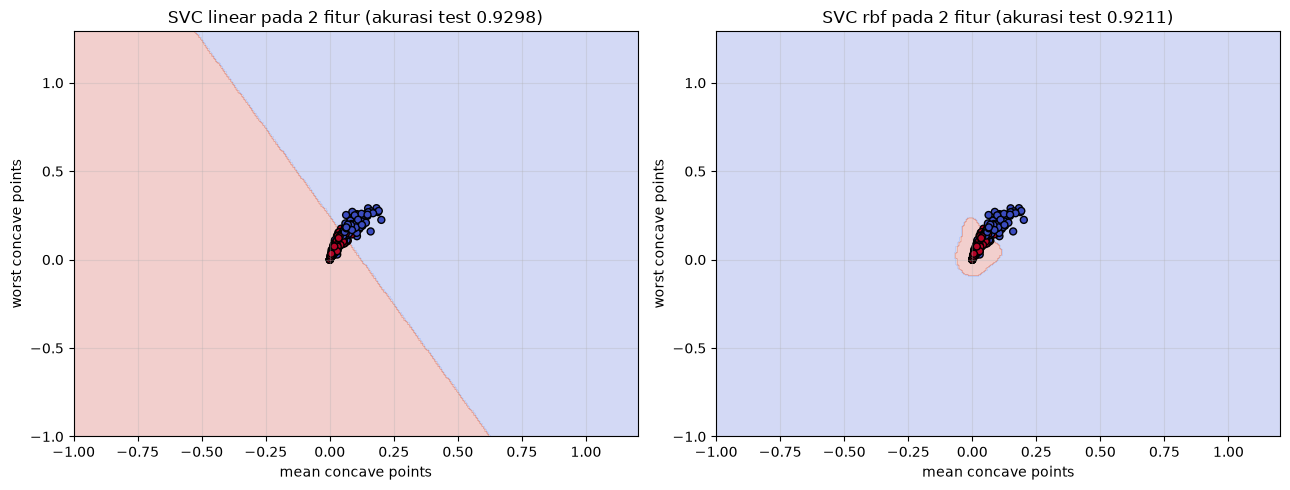

In [12]:
# Pilih 2 fitur paling informatif agar bisa divisualisasikan 2D
selector = SelectKBest(score_func=f_classif, k=2)
Xtr_2d = selector.fit_transform(Xtr_b, ytr_b)
Xte_2d = selector.transform(Xte_b)
nama_fitur = data_bc.feature_names[selector.get_support()]
print("2 fitur terpilih:", list(nama_fitur))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, kernel in zip(axes, ["linear", "rbf"]):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel=kernel, random_state=42)),
    ]).fit(Xtr_2d, ytr_b)
    acc = model.score(Xte_2d, yte_b)
    # plot memakai pipeline: prediksi langsung pada koordinat 2D asli
    x_min, x_max = Xtr_2d[:, 0].min() - 1, Xtr_2d[:, 0].max() + 1
    y_min, y_max = Xtr_2d[:, 1].min() - 1, Xtr_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
    ax.scatter(Xtr_2d[:, 0], Xtr_2d[:, 1], c=ytr_b, cmap=plt.cm.coolwarm,
               edgecolors="k", s=25)
    ax.set_title(f"SVC {kernel} pada 2 fitur (akurasi test {acc:.4f})")
    ax.set_xlabel(nama_fitur[0])
    ax.set_ylabel(nama_fitur[1])
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan output:**
1. `SelectKBest` memilih dua fitur paling diskriminatif (berdasarkan skor ANOVA F) sehingga struktur kelas masih terlihat dalam 2D.
2. Plot **linear**: batas berupa garis lurus — pada proyeksi 2 fitur ini terlihat jelas ia tidak sanggup mengikuti sebaran data yang melengkung, sehingga akurasinya di bawah RBF.
3. Plot **RBF**: batas melengkung mengikuti gugusan data dan akurasi test-nya lebih tinggi. Visualisasi ini menegaskan kembali temuan Praktikum 8.2: ketika pola data non-linear, kernel RBF unggul — bahkan setelah dimensi direduksi ke 2 fitur.

## Kesimpulan

1. **SVM mencari hyperplane dengan margin maksimum** — hanya titik-titik terdekat (support vector) yang menentukan model, sehingga SVM efisien dalam representasi dan robust terhadap outlier yang jauh dari batas.
2. **Kernel trick** memungkinkan SVM memisahkan data non-linear (seperti `make_moons`) dengan memetakan data ke ruang berdimensi tinggi secara implisit; RBF mencapai akurasi test 1,0000 di mana kernel linear hanya 0,9200.
3. **Parameter C** mengatur trade-off margin vs kesalahan training: C terlalu kecil menyebabkan underfitting (akurasi test 0,6228), C terlalu besar menyebabkan overfitting (train 1,0000 tapi test turun ke 0,9386) — nilai tengah (C=1) optimal pada percobaan ini.
4. **Scaling fitur adalah keharusan** untuk SVM: `StandardScaler` menaikkan akurasi RBF pada breast_cancer dari 0,9474 menjadi 0,9825 karena kernel RBF berbasis jarak Euclidean yang didominasi fitur berskala besar.
5. **Tidak ada model yang selalu menang** — pada 1000 sampel digits, SVC RBF, KNN, dan LogisticRegression semuanya mencapai ~0,99; pilih SVM untuk data kecil–sedang yang non-linear dan akurasi prioritas, model linear untuk data besar/butuh interpretabilitas, dan selalu validasi hyperparameter (C, gamma, kernel) secara sistematis.